In [ ]:
# RAVDESS speech emotion recognition: comparing a few model architectures
# on the same actor-level split (LSTM / CNN / CNN-LSTM / FNN / VGG16 on
# spectrograms).

import os
import re
import random
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization, LSTM,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Ensure reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
RAVDESS_ROOT = os.environ.get("RAVDESS_ROOT", "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio")

DURATION = 2.5
OFFSET = 0.6
SR = 22050
FRAME_LENGTH = 2048
HOP_LENGTH = 512
N_MFCC = 13
N_CLASSES = 8

BATCH_SIZE = 64
EPOCHS = 50

CLASS_NAMES = ["neutral", "calm", "happy", "sad","angry", "fear", "disgust", "surprise"]

EMOTION_MAP = {1: "neutral", 2: "calm", 3: "happy", 4: "sad", 5: "angry", 6: "fear", 7: "disgust", 8: "surprise",}

def set_gpu_memory_growth():
    """Configure GPU memory growth if a GPU is available; otherwise fall
    back to CPU with a warning (training will be much slower on CPU)."""
    gpus = tf.config.list_physical_devices("GPU")

    if not gpus:
        warnings.warn(
            "No GPU detected by TensorFlow; falling back to CPU. "
            "Training will be significantly slower. "
            f"TensorFlow version: {tf.__version__}"
        )
        return

    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as exc:
        warnings.warn(f"Could not configure GPU memory growth: {exc}")

    tf.config.set_visible_devices(gpus[0], "GPU")

def get_actor_id(path):
    """Extract RAVDESS actor ID from filename/path."""
    filename = os.path.basename(path)
    actor = int(filename.split("-")[-1].split(".")[0])
    return actor


def get_emotion_id(path):
    """RAVDESS filename field 3 is the emotion code."""
    filename = os.path.basename(path)
    parts = filename.split("-")
    return int(parts[2])

def build_metadata(root):
    rows = []

    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"RAVDESS directory not found: {root}\n"
            "Change RAVDESS_ROOT to the location of your dataset."
        )

    for actor_dir in sorted(os.listdir(root)):
        actor_path = os.path.join(root, actor_dir)
        if not os.path.isdir(actor_path):
            continue

        for filename in sorted(os.listdir(actor_path)):
            if not filename.lower().endswith(".wav"):
                continue

            path = os.path.join(actor_path, filename)
            emotion_id = get_emotion_id(path)
            actor_id = get_actor_id(path)

            if emotion_id not in EMOTION_MAP:
                continue

            rows.append({
                "Path": path,
                "Emotion": EMOTION_MAP[emotion_id],
                "EmotionID": emotion_id,
                "Actor": actor_id,
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["Actor", "Path"]).reset_index(drop=True)
    return df


In [ ]:
def actor_split(df, test_size=5, val_size=3, seed=SEED):
    # different actors are picked for training, testing and validation; to prevent overlapping.
    actors = np.array(sorted(df["Actor"].unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(actors)

    test_actors = sorted(actors[:test_size])
    val_actors = sorted(actors[test_size:test_size + val_size])
    train_actors = sorted(actors[test_size + val_size:])

    train_df = df[df["Actor"].isin(train_actors)].copy()
    val_df = df[df["Actor"].isin(val_actors)].copy()
    test_df = df[df["Actor"].isin(test_actors)].copy()

    return train_df, val_df, test_df, train_actors, val_actors, test_actors


In [4]:
def zcr(data, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    return np.squeeze(
        librosa.feature.zero_crossing_rate(
            data,
            frame_length=frame_length,
            hop_length=hop_length
        )
    )


def rmse(data, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    return np.squeeze(
        librosa.feature.rms(
            y=data,
            frame_length=frame_length,
            hop_length=hop_length
        )
    )


def mfcc(data, sr=SR, frame_length=FRAME_LENGTH,
         hop_length=HOP_LENGTH, flatten=True):
    values = librosa.feature.mfcc(
        y=data,
        sr=sr,
        n_mfcc=N_MFCC,
        hop_length=hop_length
    )
    values = np.squeeze(values.T)
    return np.ravel(values) if flatten else values


def extract_features(data, sr=SR):
    return np.hstack((
        zcr(data),
        rmse(data),
        mfcc(data, sr)
    )).astype(np.float32)


In [ ]:
# augmentation- only applied to training data to make it more robust for testing/ validation data
def add_noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.max(np.abs(data))
    return data + noise_amp * np.random.normal(size=data.shape[0])


def pitch_shift(data, sampling_rate, n_steps=0.7):
    return librosa.effects.pitch_shift(
        y=data,
        sr=sampling_rate,
        n_steps=n_steps
    )


def load_audio(path):
    data, sr = librosa.load(
        path,
        sr=SR,
        duration=DURATION,
        offset=OFFSET,
        mono=True
    )

    # Force every audio sample to have exactly the same length.
    target_length = int(DURATION * SR)

    if len(data) < target_length:
        # Pad shorter recordings with zeros.
        data = np.pad(
            data,
            (0, target_length - len(data)),
            mode="constant"
        )
    else:
        # Truncate anything longer than the target length.
        data = data[:target_length]

    return data.astype(np.float32), sr

def feature_variants(path, augment=False):
    # original always included, augmented versions only if augment=True (train only)
    data, sr = load_audio(path)
    variants = [data]

    if augment:
        noised = add_noise(data)
        pitched = pitch_shift(data, sr)
        pitched_noised = add_noise(pitched)
        variants.extend([noised, pitched, pitched_noised])

    return [extract_features(x, sr) for x in variants]


def build_engineered_dataset(df, augment=False):
    X, y, groups = [], [], []

    for row in df.itertuples(index=False):
        features = feature_variants(row.Path, augment=augment)
        for feat in features:
            X.append(feat)
            y.append(row.Emotion)
            groups.append(row.Actor)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)
    groups = np.asarray(groups)
    # print(X.shape, y.shape) 
    return X, y, groups


In [ ]:
# VGG16 needs actual images, so built log-mel spectrograms instead of
# reusing the flat feature vectors used for other models
def make_vgg_image(path, augment=False):
    data, sr = load_audio(path)

    if augment:
        choice = np.random.randint(0, 4)
        if choice == 1:
            data = add_noise(data)
        elif choice == 2:
            data = pitch_shift(data, sr)
        elif choice == 3:
            data = add_noise(pitch_shift(data, sr))

    mel = librosa.feature.melspectrogram(
        y=data,
        sr=sr,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH,
        n_mels=128,
        fmin=20,
        fmax=sr // 2,
        power=2.0
    )
    db = librosa.power_to_db(mel, ref=np.max)

    # Normalize each spectrogram to 0-255 for image-model input.
    db_min, db_max = db.min(), db.max()
    image = (db - db_min) / (db_max - db_min + 1e-8)
    image = (image * 255.0).astype(np.float32)

    # Resize using TensorFlow so OpenCV is not required.
    image = tf.image.resize(image[..., np.newaxis], (224, 224)).numpy()
    image = np.repeat(image, 3, axis=-1)
    return image.astype(np.float32)


def build_vgg_dataset(df, augment=False):
    X, y, groups = [], [], []
    for row in df.itertuples(index=False):
        data, sr = load_audio(row.Path)
        waves = [data]
        if augment:
            waves.extend([
                add_noise(data),
                pitch_shift(data, sr),
                add_noise(pitch_shift(data, sr))
            ])

        for wave in waves:
            mel = librosa.feature.melspectrogram(
                y=wave,
                sr=sr,
                n_fft=FRAME_LENGTH,
                hop_length=HOP_LENGTH,
                n_mels=128,
                fmin=20,
                fmax=sr // 2,
                power=2.0
            )
            db = librosa.power_to_db(mel, ref=np.max)
            db_min, db_max = db.min(), db.max()
            image = (db - db_min) / (db_max - db_min + 1e-8)
            image = (image * 255.0).astype(np.float32)
            image = tf.image.resize(image[..., np.newaxis], (224, 224)).numpy()
            image = np.repeat(image, 3, axis=-1)

            X.append(image)
            y.append(row.Emotion)
            groups.append(row.Actor)

    return np.asarray(X, dtype=np.float32), np.asarray(y), np.asarray(groups)

In [7]:
def encode_labels(train_y, val_y, test_y):
    encoder = LabelEncoder()
    encoder.fit(CLASS_NAMES)
    y_train = encoder.transform(train_y)
    y_val = encoder.transform(val_y)
    y_test = encoder.transform(test_y)
    return y_train, y_val, y_test, encoder


def one_hot(y, n_classes=N_CLASSES):
    return tf.keras.utils.to_categorical(y, num_classes=n_classes)

In [ ]:
def callbacks_for(name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

In [9]:
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(64),
        BatchNormalization(),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(N_CLASSES, activation="softmax")
    ], name="LSTM")
    return model


def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(256, 5, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),

        Conv1D(128, 5, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),

        Conv1D(64, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),

        GlobalAveragePooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(N_CLASSES, activation="softmax")
    ], name="CNN")
    return model


def build_cnn_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(256, 5, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),

        Conv1D(128, 5, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),

        Conv1D(64, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),

        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(N_CLASSES, activation="softmax")
    ], name="CNN_LSTM")
    return model


def build_fnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(N_CLASSES, activation="softmax")
    ], name="FNN")
    return model


def build_vgg16():
    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(N_CLASSES, activation="softmax")(x)

    return Model(inputs, outputs, name="VGG16")

In [ ]:
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )


def train_model(model, X_train, y_train, X_val, y_val, name):
    # GPU is already selected as the only visible device in
    # set_gpu_memory_growth() (if one exists), so ops land there
    # automatically without needing an explicit device() block here.
    compile_model(model)
    print(f"TRAINING: {name}")
    model.summary()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_for(name),
        verbose=1
    )
    return history


def evaluate_model(model, X_test, y_test, class_names, name, history=None):
    probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    pred = np.argmax(probs, axis=1)
    true = np.argmax(y_test, axis=1)

    accuracy = accuracy_score(true, pred)
    precision = precision_score(true, pred, average="macro", zero_division=0)
    recall = recall_score(true, pred, average="macro", zero_division=0)
    f1 = f1_score(true, pred, average="macro", zero_division=0)

    try:
        auc = roc_auc_score(
            y_test,
            probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        auc = np.nan

    print(f"\n{name} TEST RESULTS")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 macro : {f1:.4f}")
    print(f"AUC macro: {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(true, pred, labels=np.arange(len(class_names)), target_names=class_names, zero_division=0))

    cm = confusion_matrix(true, pred, labels=np.arange(len(class_names)))
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{name} - Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    if history is not None:
        plot_history(history, name)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision_macro": precision,
        "Recall_macro": recall,
        "F1_macro": f1,
        "AUC_macro": auc
    }, probs, pred


def plot_history(history, name):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    ax[0].plot(history.history["loss"], label="Training Loss")
    ax[0].plot(history.history["val_loss"], label="Validation Loss")
    ax[0].set_title(f"{name} - Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(history.history["accuracy"], label="Training Accuracy")
    ax[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    ax[1].set_title(f"{name} - Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()



Dataset:
Emotion
neutral      96
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
Name: count, dtype: int64
Number of recordings: 1440
Number of actors: 24


I0000 00:00:1790414242.328684     106 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


TRAINING: LSTM


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1620, 64)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1620, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1620, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,784 (233.53 KB)

 Trainable params: 59,528 (232.53 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.1674 - loss: 2.1612 - val_accuracy: 0.1389 - val_loss: 2.0734 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.2005 - loss: 2.0494 - val_accuracy: 0.1722 - val_loss: 2.0586 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.1935 - loss: 2.0357 - val_accuracy: 0.1611 - val_loss: 2.0343 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.1997 - loss: 2.0105 - val_accuracy: 0.1667 - val_loss: 2.0237 - learning_rate: 0.0010
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.2042 - loss: 1.9939 - val_accuracy: 0.1333 - val_loss: 2.0115 - learning_rate: 0.0010
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.2128 - loss: 1.9760 - val_accuracy: 0.1778 - val_loss: 1.9578 - learning_rate: 0.0010
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.2250 - loss: 1.9727 - val_ac

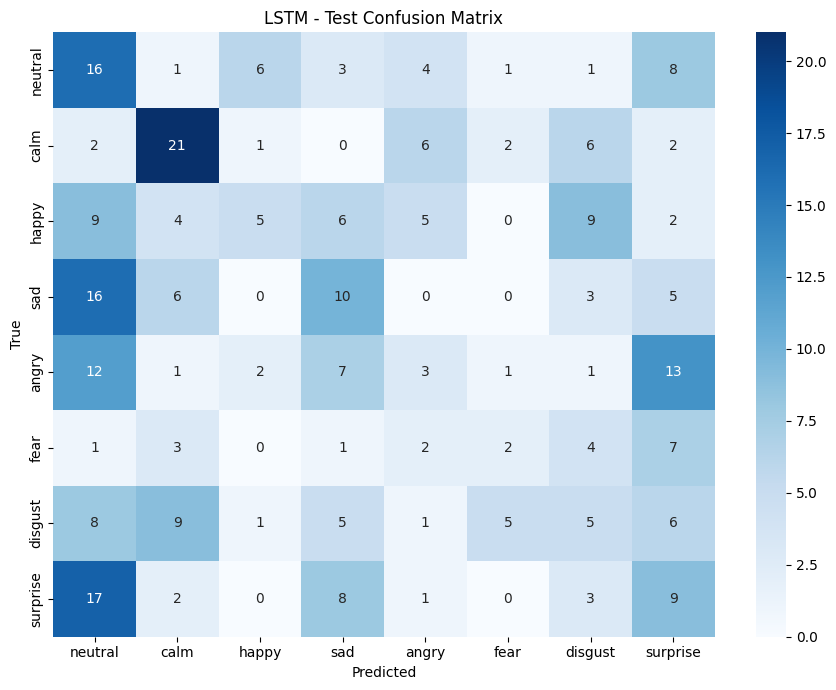

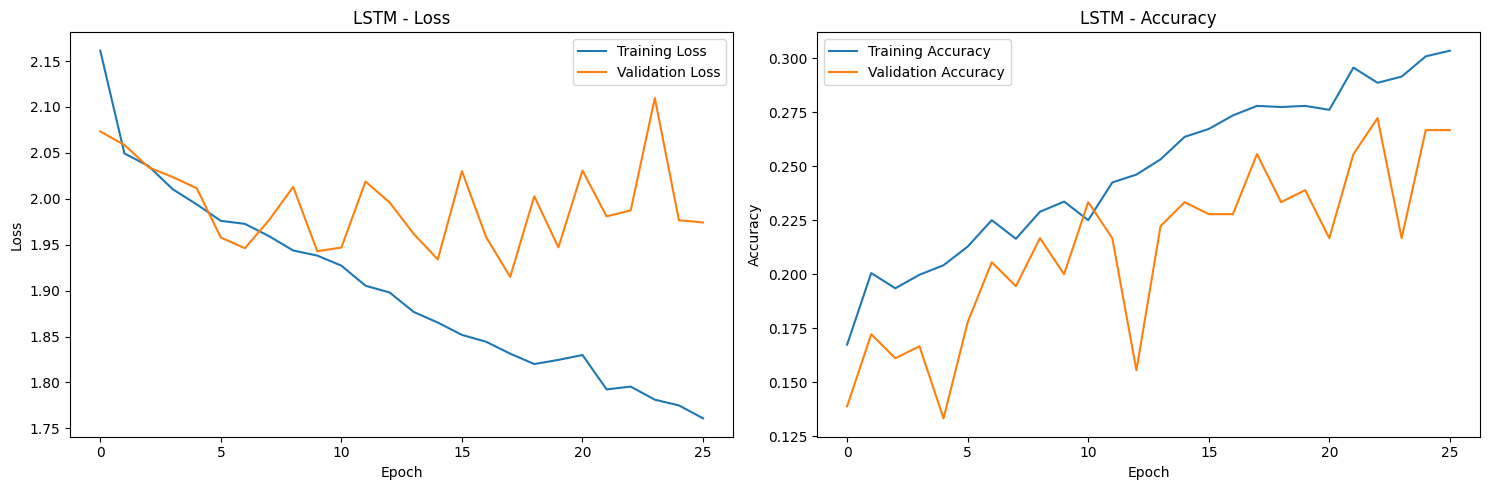

TRAINING: CNN


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1620, 256)      │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1620, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 810, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 810, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 810, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 810, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 405, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 405, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 405, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 405, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 202, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 202, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,288 (786.28 KB)

 Trainable params: 200,392 (782.78 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
 2/60 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.2031 - loss: 2.0921 

I0000 00:00:1790414400.255297     173 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.2477 - loss: 1.9382 - val_accuracy: 0.1333 - val_loss: 2.1412 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3221 - loss: 1.7601 - val_accuracy: 0.1333 - val_loss: 3.0101 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3667 - loss: 1.6537 - val_accuracy: 0.1333 - val_loss: 3.7523 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4066 - loss: 1.5711
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4036 - loss: 1.5579 - val_accuracy: 0.1278 - val_loss: 4.2085 - learning_rate: 0.0010
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4417 - loss: 1.4765 - val_accuracy: 0.1500 - val_loss: 4.3262 - learning_rate: 5.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4625 - loss: 1.4282 - val_accuracy: 

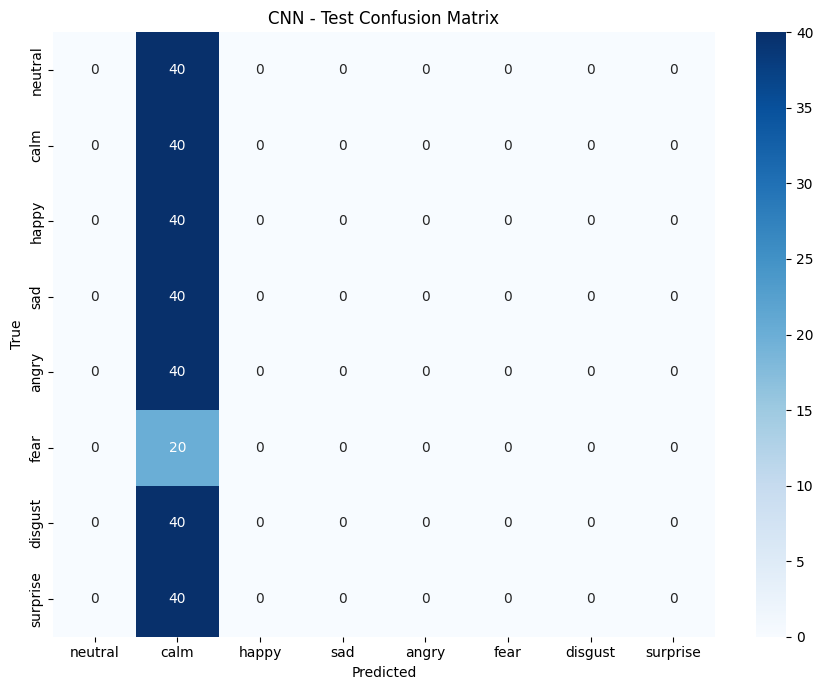

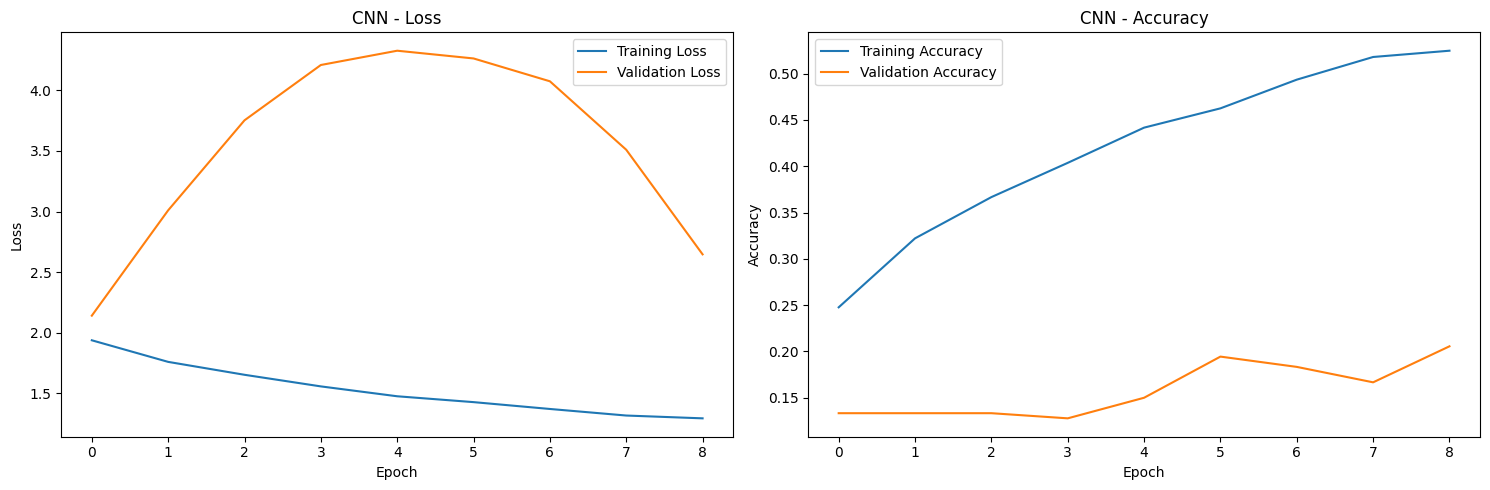

TRAINING: CNN-LSTM


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 1620, 256)      │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1620, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 810, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 810, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 810, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 810, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 405, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 405, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 405, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 405, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 202, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 202, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 202, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,512 (1.33 MB)

 Trainable params: 348,616 (1.33 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.2146 - loss: 1.9740 - val_accuracy: 0.0667 - val_loss: 2.1369 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.2448 - loss: 1.8686 - val_accuracy: 0.1333 - val_loss: 2.1725 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.2982 - loss: 1.8011 - val_accuracy: 0.1333 - val_loss: 2.3253 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3104 - loss: 1.7399
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3109 - loss: 1.7347 - val_accuracy: 0.2000 - val_loss: 2.3604 - learning_rate: 0.0010
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3469 - loss: 1.6451 - val_accuracy: 0.2056 - val_loss: 2.3275 - learning_rate: 5.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.4060 - loss: 1.5410 - val

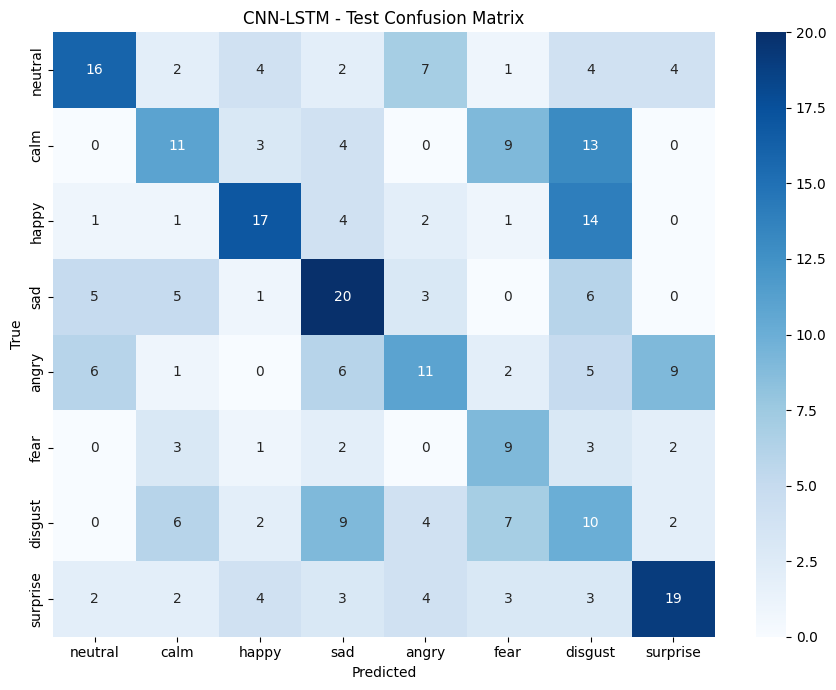

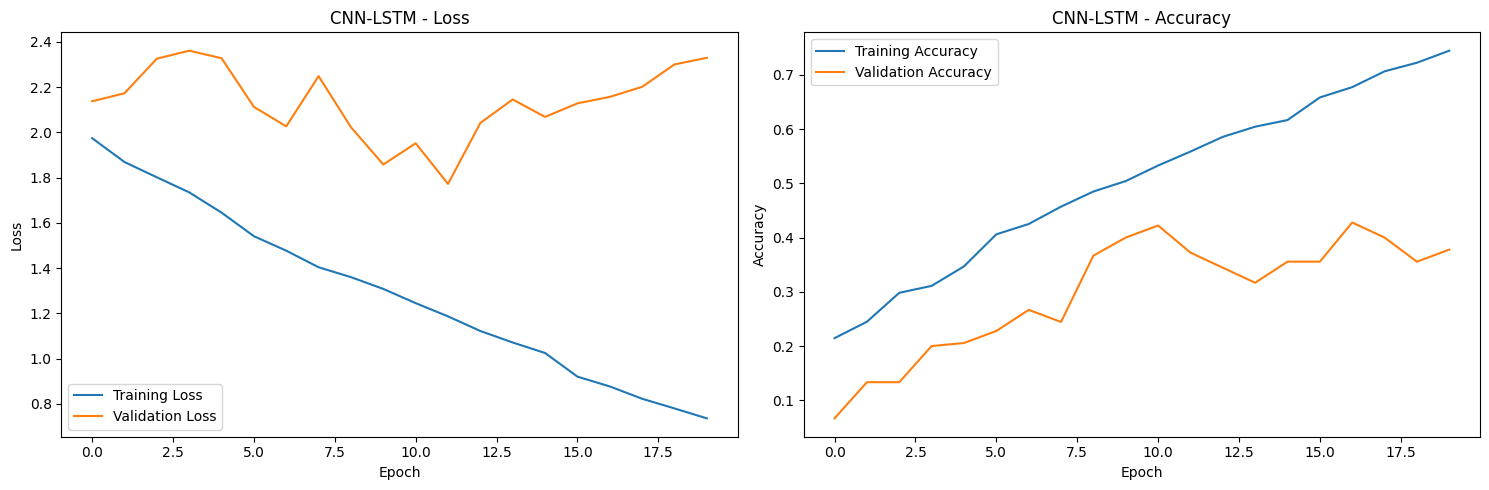

TRAINING: FNN


Model: "FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       207,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,600 (853.91 KB)

 Trainable params: 218,344 (852.91 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.3292 - loss: 1.8167 - val_accuracy: 0.3778 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5359 - loss: 1.2753 - val_accuracy: 0.4333 - val_loss: 1.6049 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6680 - loss: 0.9431 - val_accuracy: 0.4889 - val_loss: 1.6698 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7516 - loss: 0.7094 - val_accuracy: 0.5278 - val_loss: 1.7590 - learning_rate: 0.0010
Epoch 5/50
45/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7987 - loss: 0.5807
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8042 - loss: 0.5491 - val_accuracy: 0.5444 - val_loss: 1.9218 - learning_rate: 0.0010
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8617 - loss: 0.4214 - val_accuracy: 

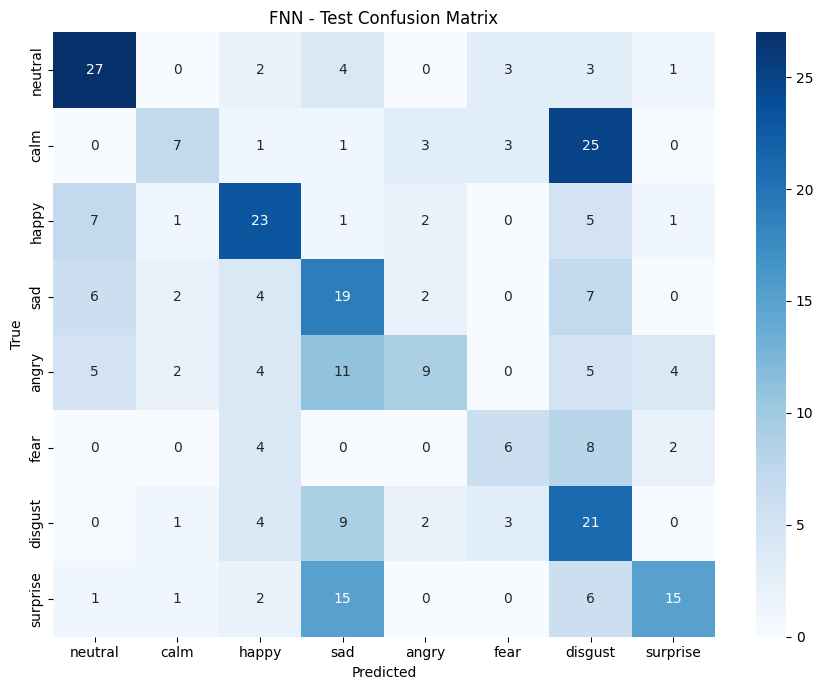

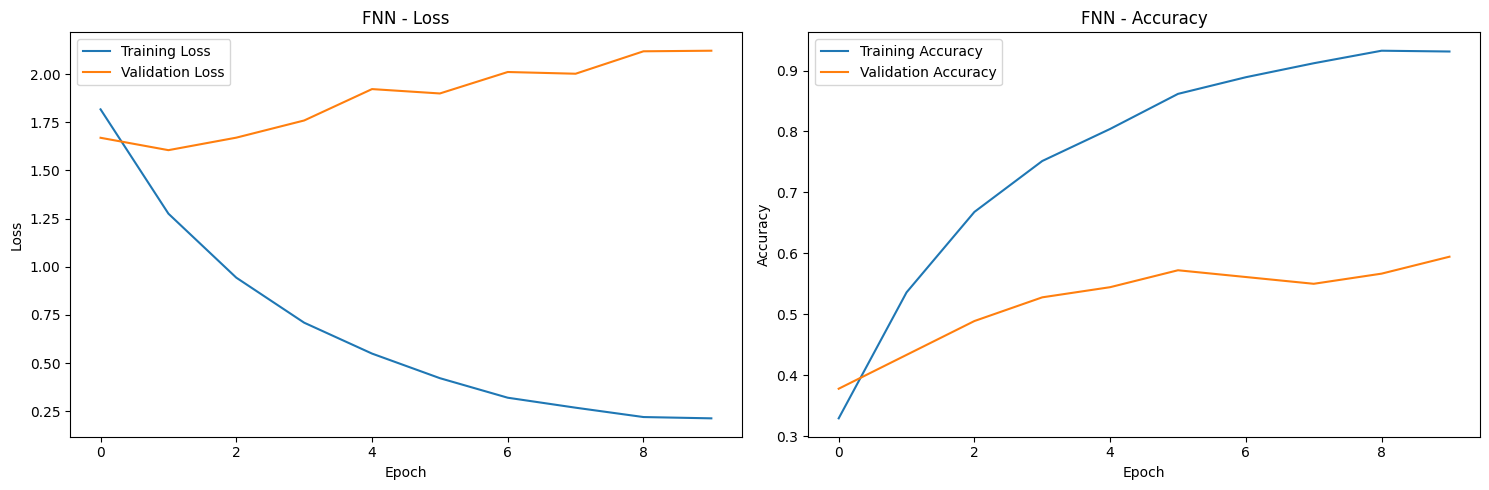


Preparing VGG16 spectrogram data...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TRAINING: VGG16


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,789,640 (56.42 MB)

 Trainable params: 74,696 (291.78 KB)

 Non-trainable params: 14,714,944 (56.13 MB)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 69s 696ms/step - accuracy: 0.2432 - loss: 2.2003 - val_accuracy: 0.3111 - val_loss: 2.0021 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 319ms/step - accuracy: 0.3805 - loss: 1.6657 - val_accuracy: 0.3944 - val_loss: 1.5708 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 320ms/step - accuracy: 0.4354 - loss: 1.5287 - val_accuracy: 0.4500 - val_loss: 1.5052 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 326ms/step - accuracy: 0.4771 - loss: 1.3991 - val_accuracy: 0.5056 - val_loss: 1.3885 - learning_rate: 0.0010
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 328ms/step - accuracy: 0.5063 - loss: 1.3253 - val_accuracy: 0.5222 - val_loss: 1.3542 - learning_rate: 0.0010
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 322ms/step - accuracy: 0.5385 - loss: 1.2388 - val_accuracy: 0.5389 - val_loss: 1.3559 - learning_rate: 0.0010
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 321ms/step - accuracy: 0.5669 - loss: 1.

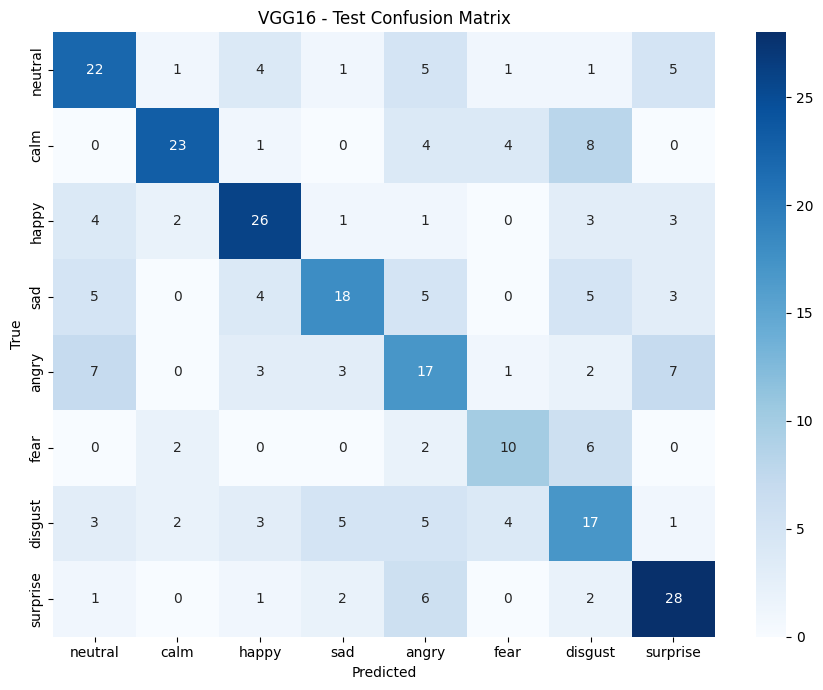

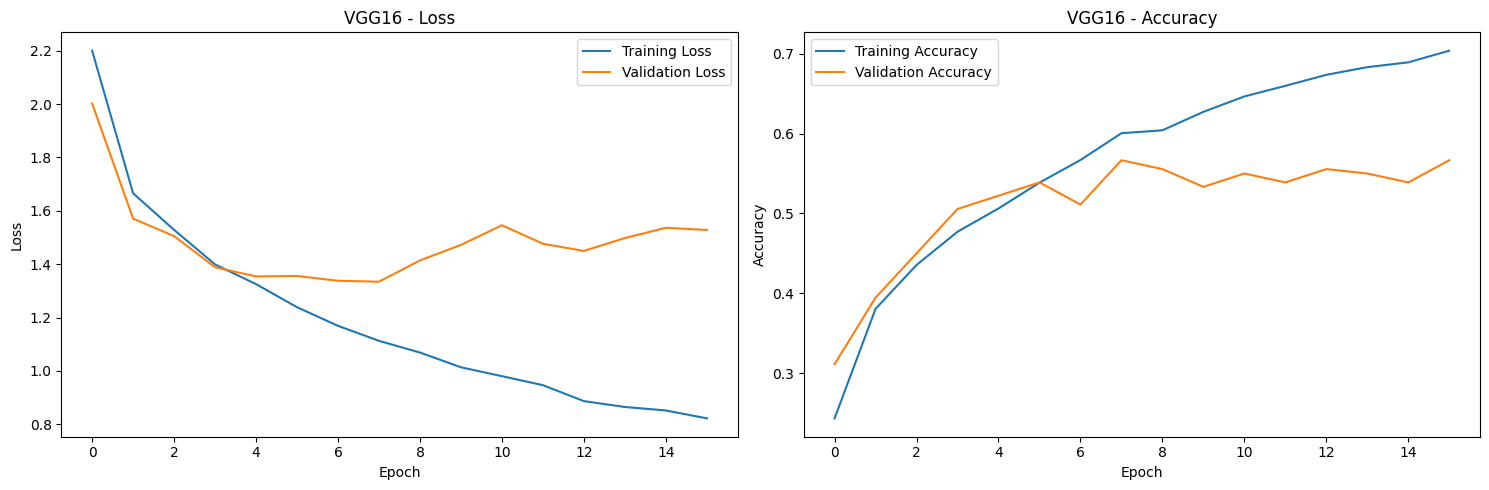

FINAL MODEL COMPARISON
   Model  Accuracy  Precision_macro  Recall_macro  F1_macro  AUC_macro
   VGG16  0.536667         0.546176      0.534375  0.536325   0.876580
     FNN  0.423333         0.467628      0.415625  0.411772   0.803789
CNN-LSTM  0.376667         0.394463      0.381250  0.380470   0.765573
    LSTM  0.236667         0.234398      0.228125  0.217423   0.694413
     CNN  0.133333         0.016667      0.125000  0.029412   0.582086


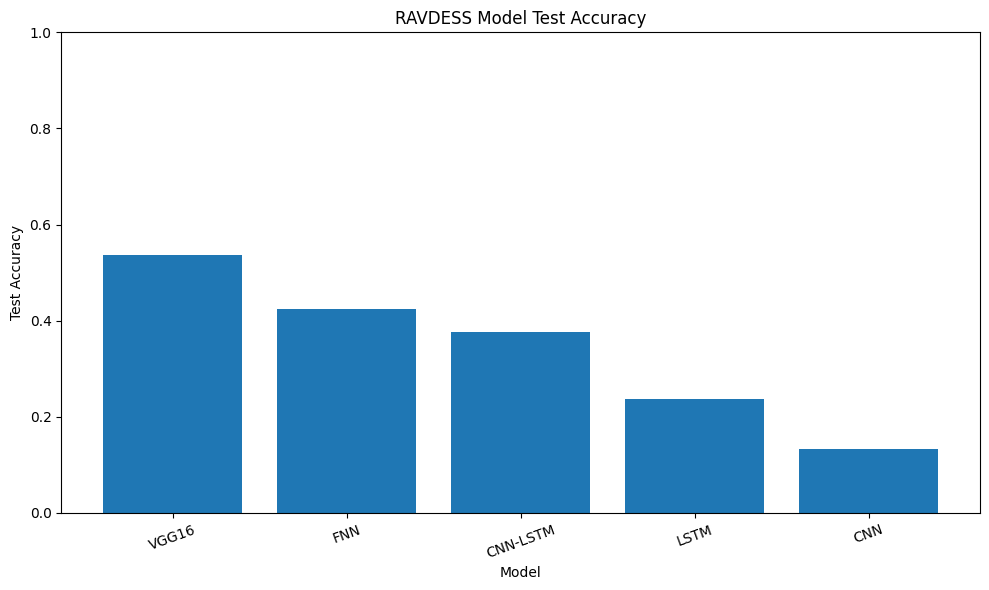


Experiment completed


In [ ]:
def main():
    # Uses GPU if available, otherwise falls back to CPU.
    set_gpu_memory_growth()

    #Metadata 
    data = build_metadata(RAVDESS_ROOT)
    data.to_csv("ravdess_file_metadata.csv", index=False)

    print("\nDataset:")
    print(data["Emotion"].value_counts().reindex(CLASS_NAMES))
    print("Number of recordings:", len(data))
    print("Number of actors:", data["Actor"].nunique())
    # print(data.head())

    train_df, val_df, test_df, train_actors, val_actors, test_actors = actor_split(data)

    assert set(train_actors).isdisjoint(val_actors)
    assert set(train_actors).isdisjoint(test_actors)
    assert set(val_actors).isdisjoint(test_actors)

    #common input for LSTM/CNN/CNN-LSTM/FNN
    X_train_raw, y_train_raw, _ = build_engineered_dataset(train_df, augment=True)
    X_val_raw, y_val_raw, _ = build_engineered_dataset(val_df, augment=False)
    X_test_raw, y_test_raw, _ = build_engineered_dataset(test_df, augment=False)

    # Fit scaler only on training data.
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)
    X_test = scaler.transform(X_test_raw).astype(np.float32)
    y_train_int, y_val_int, y_test_int, encoder = encode_labels(
        y_train_raw, y_val_raw, y_test_raw
    )

    y_train = one_hot(y_train_int)
    y_val = one_hot(y_val_int)
    y_test = one_hot(y_test_int)

    #LSTM
    X_train_seq = X_train[..., np.newaxis]
    X_val_seq = X_val[..., np.newaxis]
    X_test_seq = X_test[..., np.newaxis]

    model_lstm = build_lstm((X_train_seq.shape[1], 1))
    hist_lstm = train_model(
        model_lstm, X_train_seq, y_train, X_val_seq, y_val, "LSTM"
    )
    result_lstm, _, _ = evaluate_model(
        model_lstm, X_test_seq, y_test, CLASS_NAMES, "LSTM", hist_lstm
    )

    #CNN
    model_cnn = build_cnn((X_train_seq.shape[1], 1))
    hist_cnn = train_model(
        model_cnn, X_train_seq, y_train, X_val_seq, y_val, "CNN"
    )
    result_cnn, _, _ = evaluate_model(
        model_cnn, X_test_seq, y_test, CLASS_NAMES, "CNN", hist_cnn
    )

    #CNN-LSTM
    model_cnn_lstm = build_cnn_lstm((X_train_seq.shape[1], 1))
    hist_cnn_lstm = train_model(
        model_cnn_lstm,
        X_train_seq,
        y_train,
        X_val_seq,
        y_val,
        "CNN-LSTM"
    )
    result_cnn_lstm, _, _ = evaluate_model(
        model_cnn_lstm,
        X_test_seq,
        y_test,
        CLASS_NAMES,
        "CNN-LSTM",
        hist_cnn_lstm
    )

    #FNN
    model_fnn = build_fnn(X_train.shape[1])
    hist_fnn = train_model(
        model_fnn, X_train, y_train, X_val, y_val, "FNN"
    )
    result_fnn, _, _ = evaluate_model(
        model_fnn, X_test, y_test, CLASS_NAMES, "FNN", hist_fnn
    )

    #VGG16 on real log-Mel spectrogram images
    print("\nPreparing VGG16 spectrogram data...")
    X_train_vgg, y_train_vgg_raw, _ = build_vgg_dataset(train_df, augment=True)
    X_val_vgg, y_val_vgg_raw, _ = build_vgg_dataset(val_df, augment=False)
    X_test_vgg, y_test_vgg_raw, _ = build_vgg_dataset(test_df, augment=False)
    
    X_train_vgg = preprocess_input(X_train_vgg)
    X_val_vgg = preprocess_input(X_val_vgg)
    X_test_vgg = preprocess_input(X_test_vgg)

    y_train_vgg_int, y_val_vgg_int, y_test_vgg_int, _ = encode_labels(y_train_vgg_raw, y_val_vgg_raw, y_test_vgg_raw)
    y_train_vgg = one_hot(y_train_vgg_int)
    y_val_vgg = one_hot(y_val_vgg_int)
    y_test_vgg = one_hot(y_test_vgg_int)

    model_vgg16 = build_vgg16()
    hist_vgg16 = train_model(
        model_vgg16,
        X_train_vgg,
        y_train_vgg,
        X_val_vgg,
        y_val_vgg,
        "VGG16"
    )
    result_vgg16, _, _ = evaluate_model(
        model_vgg16,
        X_test_vgg,
        y_test_vgg,
        CLASS_NAMES,
        "VGG16",
        hist_vgg16
    )
    
    # Final comparison table
    results = pd.DataFrame([
        result_lstm,
        result_cnn,
        result_cnn_lstm,
        result_vgg16,
        result_fnn
    ])

    results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
    results.to_csv("ravdess_model_comparison_results.csv", index=False)
    print("FINAL MODEL COMPARISON")
    print(results.to_string(index=False))

    # Plot comparison without implying a ranking beyond the measured metric.
    plt.figure(figsize=(10, 6))
    plt.bar(results["Model"], results["Accuracy"])
    plt.ylabel("Test Accuracy")
    plt.xlabel("Model")
    plt.title("RAVDESS Model Test Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print("\nExperiment completed")
    return results


if __name__ == "__main__":
    results = main()